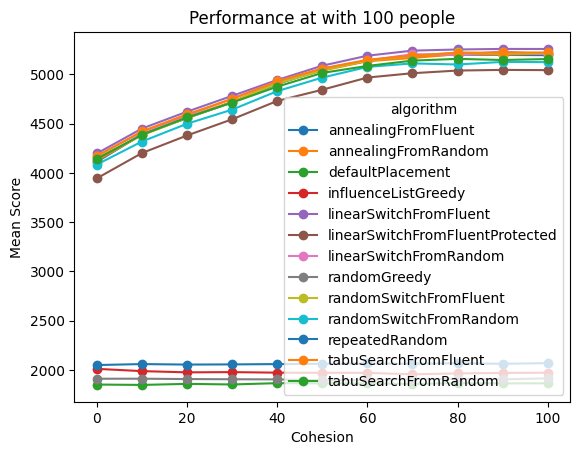

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('flattened_experiments_data.csv')

# Convert score and time to numeric types, coercing invalid values to NaN
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['time'] = pd.to_numeric(df['time'], errors='coerce')

# Remove rows with NaN values
df = df.dropna()

# print(df)

summary = df.groupby(["algorithm", "n_people", "cohesion"]).agg(
    mean_score=("score", "mean"),
    std_score=("score", "std"),
    mean_time=("time", "mean"),
    std_time=("time", "std"),
).reset_index()

summary_c0 = summary[summary["n_people"] == 100]

# print(summary)

summary_c0.pivot(
    index="cohesion",
    columns="algorithm",
    values="mean_score"
).plot(
    title="Performance at with 100 people",
    xlabel="Cohesion",
    ylabel="Mean Score",
    marker="o",
    colormap="tab20"
)

plt.show()

In [5]:
import pandas as pd

# Load data
df = pd.read_csv("flattened_experiments_data.csv")

# Mark DNFs before conversion
df["is_dnf"] = df["score"] == "DNF"

# Convert to numeric (DNF -> NaN)
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["time"] = pd.to_numeric(df["time"], errors="coerce")

# Group and compute everything
result = df.groupby("algorithm").agg(
    avg_score=("score", "mean"),
    avg_time=("time", "mean"),
    total_runs=("score", "size"),
    dnf_count=("is_dnf", "sum")
)

# Compute percentage
result["dnf_percentage"] = (result["dnf_count"] / result["total_runs"]) * 100

# Optional: valid runs
result["valid_runs"] = result["total_runs"] - result["dnf_count"]

# Sort (optional)
result = result.sort_values(by="avg_score", ascending=False)

# Round for readability
result = result.round({
    "avg_score": 2,
    "avg_time": 4,
    "dnf_percentage": 2
})

print(result)

                                 avg_score  avg_time  total_runs  dnf_count  \
algorithm                                                                     
randomSwitchFromFluent             4767.95    3.3156        5000          4   
tabuSearchFromFluent               4689.42    7.0371        5000         35   
randomSwitchFromRandom             4613.34    3.7150        5000          0   
annealingFromRandom                4270.05    4.8098        5000          0   
annealingFromFluent                4268.05    4.5430        5000          4   
tabuSearchFromRandom               3613.03    7.4557        5000        516   
linearSwitchFromFluentProtected    2777.72    2.3487        5000        909   
repeatedRandom                     2010.74    0.3465        5000          0   
linearSwitchFromFluent             2009.72    6.3137        5000       1195   
influenceListGreedy                1945.54    0.0615        5000          0   
randomGreedy                       1895.12    0.0758

In [6]:
def analyze_for_n(df, n_people):
    df_n = df[df["n_people"] == n_people].copy()

    df_n["is_dnf"] = df_n["score"] == "DNF"
    df_n["score"] = pd.to_numeric(df_n["score"], errors="coerce")
    df_n["time"] = pd.to_numeric(df_n["time"], errors="coerce")

    result = df_n.groupby("algorithm").agg(
        avg_score=("score", "mean"),
        avg_time=("time", "mean"),
        total_runs=("score", "size"),
        dnf_count=("is_dnf", "sum")
    )

    result["dnf_percentage"] = (result["dnf_count"] / result["total_runs"]) * 100
    result["valid_runs"] = result["total_runs"] - result["dnf_count"]

    return result.sort_values(by="avg_score", ascending=False).round(2)